<div style="background:linear-gradient(135deg,#191414,#1DB954,#191414);padding:52px 40px;border-radius:16px;text-align:center;margin-bottom:8px">
  <p style="color:#1DB954;font-size:12px;letter-spacing:4px;text-transform:uppercase;margin-bottom:14px;font-weight:700">Hands-On Machine Learning Lab</p>
  <h1 style="color:#ffffff;font-size:42px;margin:0 0 12px;font-weight:900">KNN From Scratch</h1>
  <h2 style="color:#b3b3b3;font-size:20px;font-weight:300;margin:0 0 22px">Can a Machine Hear the Difference Between EDM and Rock?</h2>
  <p style="color:#b3b3b3;font-size:14px;max-width:600px;margin:0 auto 26px;line-height:1.9">
    You will implement K-Nearest Neighbors from scratch using only NumPy and use it to
    classify 6 Spotify music genres — EDM, Latin, Pop, R&B, Rap, and Rock —
    purely from their audio features: tempo, energy, danceability, and more.
  </p>
  <div style="display:flex;justify-content:center;gap:28px;flex-wrap:wrap;font-size:13px;color:#1DB954">
    <span>&#8987; 2 to 2.5 hours</span>
    <span>&#127925; 6 Genres</span>
    <span>&#127926; 10 Audio Features</span>
    <span>&#129504; Intermediate</span>
  </div>
</div>

---

## What You Will Build

| Part | Topic | What You Do |
|------|-------|-------------|
| **1** | Meet the Data | Load Spotify songs, explore audio features |
| **2** | Visualise | Plot genre distributions and feature profiles |
| **3** | Preprocess | Clean, balance, split, and scale |
| **4** | Distance Functions | Implement Euclidean and Manhattan from scratch |
| **5** | KNN Class | Build the complete classifier using only NumPy |
| **6** | First Run | Train, predict, and read a 6-class confusion matrix |
| **7** | Tuning K | Find the best K by sweeping accuracy |
| **8** | Distance Metrics | Compare Euclidean vs Manhattan |
| **9** | Sklearn Benchmark | Match sklearn accuracy with your own code |
| **Bonus** | Deep Dive | Which genres are hardest? Predict your own song |

---

## The Audio Features You Will Use

Each song in the dataset has these 10 numerical features measured by Spotify's audio analysis:

| Feature | Range | What It Measures |
|---------|-------|-----------------|
| `danceability` | 0 to 1 | How suitable the song is for dancing |
| `energy` | 0 to 1 | Intensity and activity level |
| `loudness` | -60 to 0 dB | Overall volume |
| `speechiness` | 0 to 1 | Presence of spoken words |
| `acousticness` | 0 to 1 | How acoustic (vs electronic) the song is |
| `instrumentalness` | 0 to 1 | Likelihood of no vocals |
| `liveness` | 0 to 1 | Presence of a live audience |
| `valence` | 0 to 1 | Musical positivity / happiness |
| `tempo` | BPM | Beats per minute |
| `duration_ms` | ms | Song length in milliseconds |

---

## How to Use This Notebook

- Cells with `???` are tasks you must complete.
- **HINTS** give you the right function names — not the answer.
- **Auto-test** cells check your work and print PASS or FAIL.
- Complete every task in order — each one builds on the last.


---

## Part 0 — Imports

Run this once before anything else.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']    = (12, 5)
plt.rcParams['font.size']         = 12
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

# Spotify brand colours for the 6 genres
GENRE_COLORS = {
    'edm':   '#1DB954',
    'latin': '#FF6B35',
    'pop':   '#E91E8C',
    'r&b':   '#9B59B6',
    'rap':   '#F39C12',
    'rock':  '#E74C3C',
}
GENRES = ['edm', 'latin', 'pop', 'r&b', 'rap', 'rock']

print('Libraries loaded.')
print('Spotify genre colours set: edm=green, latin=orange, pop=pink, r&b=purple, rap=yellow, rock=red')


Libraries loaded.
Spotify genre colours set: edm=green, latin=orange, pop=pink, r&b=purple, rap=yellow, rock=red


---

## Part 1 — Load the Spotify Dataset

### Where the Data Comes From

This dataset comes from the **TidyTuesday** open data project and contains
~32,000 Spotify tracks from 6 playlist genres. Each row is one song.
It is loaded directly from GitHub — no download required.

The original dataset has 23 columns. We will work with just the 10 numerical
audio features and the `playlist_genre` column as our target.

---

### Task 1.1 — Load and Inspect

**INSTRUCTIONS:**
1. Load the CSV from the URL provided below
2. Print the shape, the 6 unique genres, and the column names
3. Display the first 5 rows

**Expected output:**
```
Shape: (32833, 23)
Genres: ['edm', 'latin', 'pop', 'r&b', 'rap', 'rock']
```

**HINT:**
```python
url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv'
df  = pd.read_csv(url)
```


In [ ]:
# ── TASK 1.1 ── Load and inspect the Spotify dataset ─────────────────────────

URL = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv'

# Step 1: Load the CSV
print('Downloading Spotify dataset from GitHub...')
df = pd.read_csv(URL)
print('Done.')
print()

# Step 2: Print shape and genres
print('Shape:', df.shape)
print('Genres:', df['playlist_genre'].unique())
print()
print('Column names:')
print(list(df.columns))
print()

# Step 3: Show first 5 rows
df.head()




Done.

Shape: (32833, 23)
Genres: ['pop' 'rap' 'rock' 'latin' 'r&b' 'edm']

Column names:
['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']



,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


### Task 1.2 — Understand the Genre Distribution

Before anything else, check how many songs each genre has.
This tells us whether the dataset is balanced or not.

**INSTRUCTIONS:**
1. Count how many songs per genre using `df['playlist_genre'].value_counts()`
2. Create a bar chart showing the counts
3. Use the `GENRE_COLORS` dictionary to colour each bar its genre colour
4. Add count labels on top of each bar

**HINT:**
```python
counts = df['playlist_genre'].value_counts()
# To colour each bar differently:
colors = [GENRE_COLORS[g] for g in counts.index]
```


Genre counts: Counter({'edm': 6043, 'rap': 5746, 'pop': 5507, 'r&b': 5431, 'latin': 5155, 'rock': 4951})


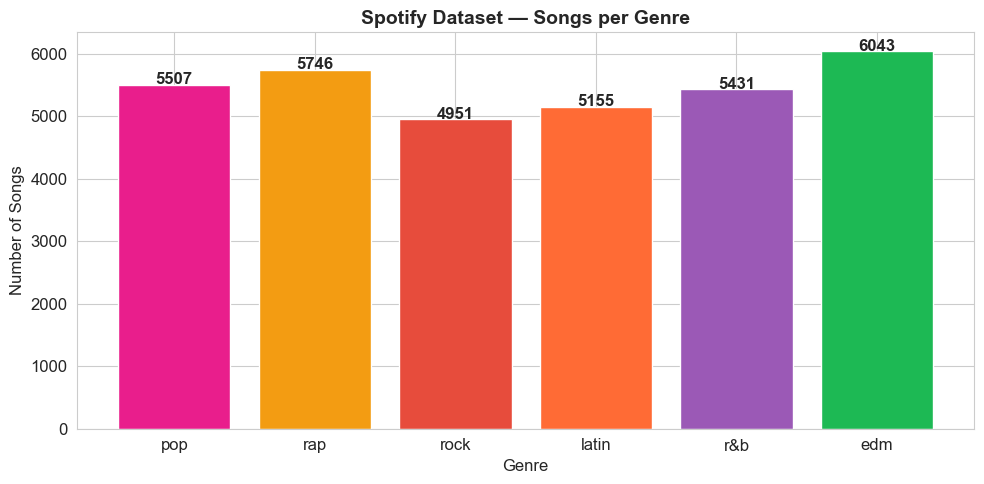

Observation: Is the dataset balanced (equal counts) or imbalanced?
This matters because KNN tends to predict the majority class too often.


In [5]:
# ── TASK 1.2 ── Genre distribution bar chart ──────────────────────────────────

counts = Counter(df['playlist_genre'])
print('Genre counts:', counts)

fig, ax = plt.subplots(figsize=(10, 5))

# YOUR CODE HERE ---------------------------------------------------------------
# Plot a bar chart using genre-specific colours
# Add count labels on top of each bar
genres = list(counts.keys())
values = list(counts.values())
colors = [GENRE_COLORS[genre] for genre in genres]
ax.bar(genres, values, color=colors)
for i, v in enumerate(values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

ax.set_title('Spotify Dataset — Songs per Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Songs')
plt.tight_layout()
plt.savefig('01_genre_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print('Observation: Is the dataset balanced (equal counts) or imbalanced?')
print('This matters because KNN tends to predict the majority class too often.')


---

## Part 2 — Visualise the Audio Features

Before writing any model, we need to understand the data visually.
The key question: **do different genres actually sound different in these features?**

If genres are indistinguishable in the feature space, KNN will struggle.
If they cluster cleanly, KNN will do well.

---

### Task 2.1 — Feature Distributions by Genre

Pick **4 features** and plot their distributions across genres.
Overlapping histograms or box plots both work.

**Suggested features to visualise:**
- `danceability` — rap and latin should be high, rock low
- `energy` — edm and rock should be high, r&b lower
- `acousticness` — rock/latin should vary, edm should be very low
- `valence` — pop and latin tend to be happier (higher)

**INSTRUCTIONS:**
Create a 2x2 subplot grid with one feature per panel.
For each panel, plot a box plot (or violin plot) across the 6 genres.
Colour each genre using `GENRE_COLORS`.

**HINTS:**
```python
# Box plot per genre using seaborn:
sns.boxplot(data=df, x='playlist_genre', y='danceability',
            palette=GENRE_COLORS, ax=ax, order=GENRES)

# Or manually:
data_per_genre = [df[df['playlist_genre']==g]['danceability'].values for g in GENRES]
ax.boxplot(data_per_genre, labels=GENRES, patch_artist=True)
```


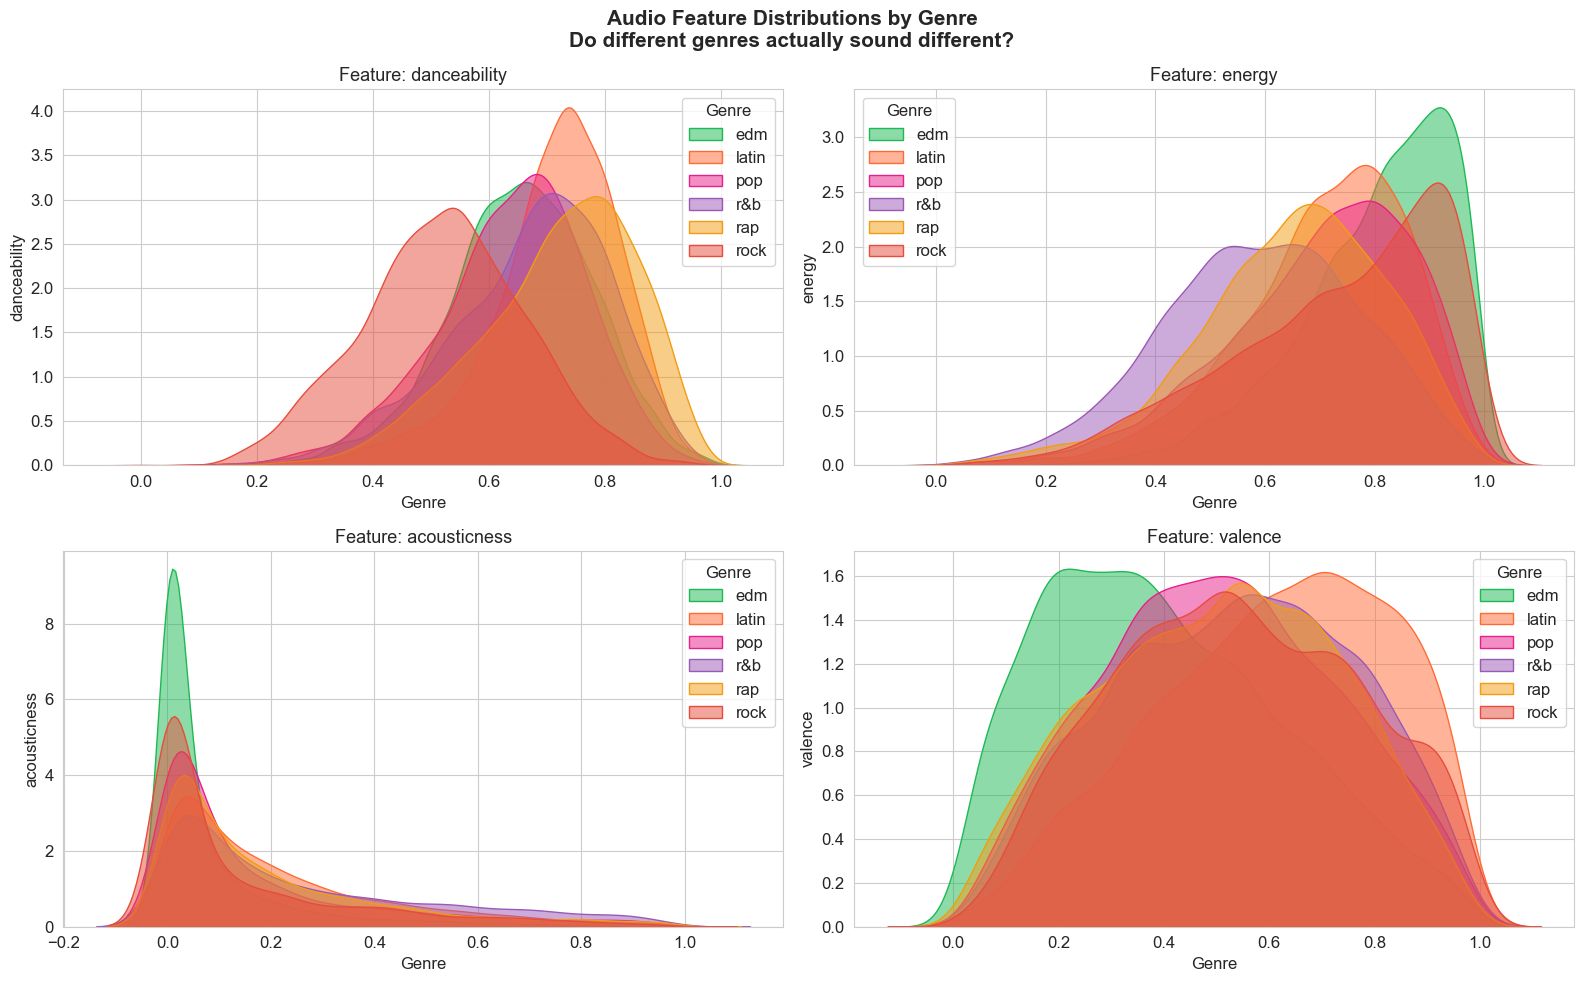

Which feature shows the CLEAREST separation between genres?
>>> Your answer: ...


In [6]:
# ── TASK 2.1 ── Feature distributions by genre ────────────────────────────────

features_to_plot = ['danceability', 'energy', 'acousticness', 'valence']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Audio Feature Distributions by Genre\n'
             'Do different genres actually sound different?',
             fontsize=15, fontweight='bold')

for ax, feature in zip(axes.ravel(), features_to_plot):
    # YOUR CODE HERE -----------------------------------------------------------
    # Plot distributions for all 6 genres on this axis
    # Use GENRE_COLORS for consistent colouring
    for genre in GENRES:
        sns.kdeplot(df[df['playlist_genre'] == genre][feature], 
                    label=genre, ax=ax, fill=True, alpha=0.5, color=GENRE_COLORS[genre])
    ax.legend(title='Genre')

    ax.set_title(f'Feature: {feature}')
    ax.set_xlabel('Genre')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.savefig('02_feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

# After running, fill in this observation:
print('Which feature shows the CLEAREST separation between genres?')
print('>>> Your answer: ...')


### Task 2.2 — The Feature Fingerprint: Average Radar Profile per Genre

This is the most insightful visualisation in the lab.
Each genre has a unique "audio fingerprint" — a characteristic pattern across features.

**INSTRUCTIONS:**
Create a single plot showing the **mean value of 6 features** for each genre as a bar group.

Features to compare: `danceability`, `energy`, `speechiness`, `acousticness`, `valence`, `liveness`

Normalise them to [0, 1] first so they are on the same scale.

**HINTS:**
```python
# Compute mean per genre for selected features
selected = ['danceability', 'energy', 'speechiness', 'acousticness', 'valence', 'liveness']
genre_means = df.groupby('playlist_genre')[selected].mean()

# This gives a DataFrame: rows=genres, columns=features
# You can plot as grouped bars:
genre_means.plot(kind='bar', ax=ax)
# Or transpose and plot genres as lines:
genre_means.T.plot(ax=ax)
```


Genre means (first 5 rows):
  playlist_genre  danceability    energy  speechiness  acousticness   valence  \
0            edm      0.655041  0.802476     0.086695      0.081504  0.400656   
1          latin      0.713287  0.708312     0.102653      0.210920  0.605510   
2            pop      0.639302  0.701028     0.073991      0.170794  0.503521   
3            r&b      0.670179  0.590934     0.116792      0.259904  0.531231   
4            rap      0.718353  0.650708     0.197506      0.192479  0.505090   

   liveness  
0  0.211859  
1  0.180626  
2  0.176833  
3  0.175268  
4  0.191654  


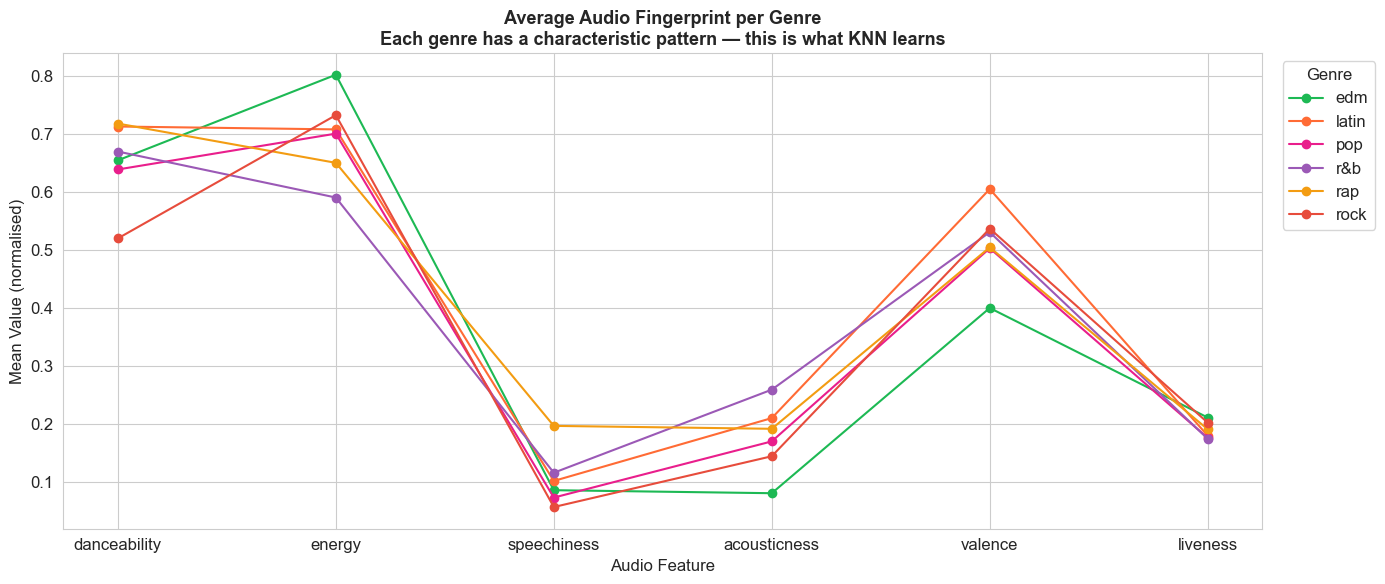

Which two genres look most SIMILAR to each other in this chart?
Those will be the hardest for KNN to tell apart.
>>> Your prediction: ...


In [8]:
# ── TASK 2.2 ── Genre audio fingerprints ──────────────────────────────────────

selected_features = ['danceability', 'energy', 'speechiness',
                     'acousticness', 'valence', 'liveness']

# Step 1: Compute mean per genre
genre_means = df.groupby('playlist_genre')[selected_features].mean().reset_index()
print('Genre means (first 5 rows):')
print(genre_means.head())


# Step 2: Plot grouped bars (genres as lines or bars, features on x-axis)
fig, ax = plt.subplots(figsize=(14, 6))

# YOUR CODE HERE ------------------------------------------------------------
grouped = genre_means.set_index('playlist_genre')
T = grouped.T
for genre in GENRES:
    ax.plot(T.index, T[genre], label=genre, marker='o', color=GENRE_COLORS[genre])


ax.set_title('Average Audio Fingerprint per Genre\n'
             'Each genre has a characteristic pattern — this is what KNN learns',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Audio Feature')
ax.set_ylabel('Mean Value (normalised)')
ax.legend(title='Genre', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('03_genre_fingerprints.png', dpi=120, bbox_inches='tight')
plt.show()

print('Which two genres look most SIMILAR to each other in this chart?')
print('Those will be the hardest for KNN to tell apart.')
print('>>> Your prediction: ...')


### Task 2.3 — Scatter Plot: Danceability vs Energy

A 2D scatter of two features coloured by genre gives you a direct feel for
how well the classes separate in feature space.

**INSTRUCTIONS:**
- Plot `danceability` (x-axis) vs `energy` (y-axis)
- Colour each point by its genre using `GENRE_COLORS`
- Use `alpha=0.3` and small marker size (`s=8`) so overlapping points are visible
- Add a legend

**HINT:**
```python
for genre in GENRES:
    subset = df[df['playlist_genre'] == genre]
    ax.scatter(subset['danceability'], subset['energy'],
               c=GENRE_COLORS[genre], label=genre, alpha=0.3, s=8)
```


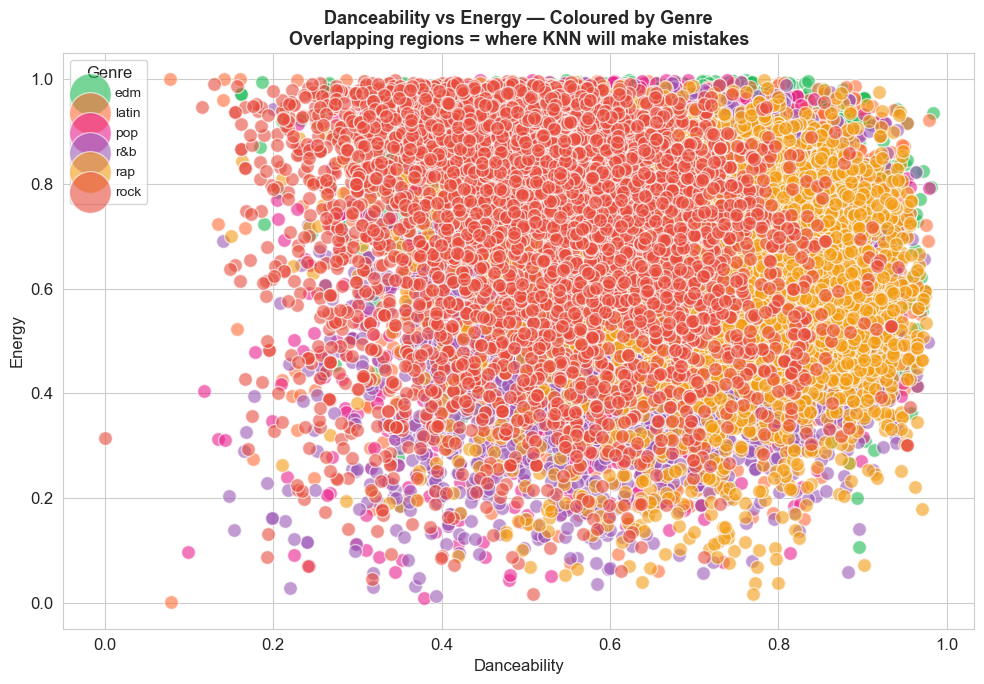

Where do you see the most overlap between genres?
>>> Your observation: ...
My obxervation is that the most overlap between genres is between pop and r&b, as they both have similar levels of danceability and energy.


In [23]:
# ── TASK 2.3 ── Scatter: danceability vs energy by genre ──────────────────────

fig, ax = plt.subplots(figsize=(10, 7))

# YOUR CODE HERE ---------------------------------------------------------------
for genre in GENRES:
    subset = df[df['playlist_genre'] == genre]
    ax.scatter(subset['danceability'], subset['energy'], 
               label=genre, alpha=0.6, edgecolor='w', s=100, color=GENRE_COLORS[genre])

ax.set_xlabel('Danceability', fontsize=12)
ax.set_ylabel('Energy', fontsize=12)
ax.set_title('Danceability vs Energy — Coloured by Genre\n'
             'Overlapping regions = where KNN will make mistakes',
             fontsize=13, fontweight='bold')
ax.legend(title='Genre', markerscale=3, fontsize=10)

plt.tight_layout()
plt.savefig('04_scatter_2d.png', dpi=120, bbox_inches='tight')
plt.show()

print('Where do you see the most overlap between genres?')
print('>>> Your observation: ...')
print('My obxervation is that the most overlap between genres is between pop and r&b, as they both have similar levels of danceability and energy.')


---

## Part 3 — Preprocessing

### What Needs Fixing Before Modelling

The raw dataset has a few issues we must handle:

1. **Duplicate songs** — the same track appears in multiple playlists.
   If the same song is in both train and test, the model is effectively memorising it.
   We must deduplicate on `track_id` first.

2. **Class imbalance** — some genres have more songs than others.
   We will balance the dataset by taking the same number of songs from each genre.

3. **Feature selection** — we only need the 10 numerical audio features.

4. **Subsampling** — our scratch KNN uses Python loops.
   To keep runtime under 1 minute, we will work with ~900 songs total (150 per genre).

5. **Encoding** — our model needs numbers, not strings like "rock".
   We use `LabelEncoder` to convert genre names to integers.

---

### Task 3.1 — Clean and Balance the Dataset

**INSTRUCTIONS:**
1. Drop duplicate rows based on `track_id`
2. Print how many songs remain after deduplication
3. For each genre, sample exactly 150 songs (use `random_state=42`)
4. Combine them into one balanced DataFrame called `df_balanced`
5. Print the shape and verify all genres have exactly 150 rows

**HINT:**
```python
# Deduplicate
df_clean = df.drop_duplicates(subset='track_id')

# Sample 150 per genre and combine
samples = [df_clean[df_clean['playlist_genre']==g].sample(150, random_state=42)
           for g in GENRES]
df_balanced = pd.concat(samples).reset_index(drop=True)
```


In [10]:
# ── TASK 3.1 ── Clean and balance ─────────────────────────────────────────────

# Step 1: Remove duplicate tracks
df_clean = df.drop_duplicates(subset=['track_id'])
print(f'After deduplication: {len(df_clean)} unique tracks (was {len(df)})')

# Step 2: Sample 150 songs per genre
SONGS_PER_GENRE = 150
samples         = []
df_balanced     = pd.DataFrame()
for genre in GENRES:
    genre_subset = df_clean[df_clean['playlist_genre'] == genre]
    sample = genre_subset.sample(n=SONGS_PER_GENRE, random_state=42)
    samples.append(sample)
df_balanced = pd.concat(samples).reset_index(drop=True)

# Step 3: Verify
print(f'Balanced dataset shape: {df_balanced.shape}')
print('Songs per genre:')
print(df_balanced['playlist_genre'].value_counts().sort_index())


After deduplication: 28356 unique tracks (was 32833)
Balanced dataset shape: (900, 23)
Songs per genre:
playlist_genre
edm      150
latin    150
pop      150
r&b      150
rap      150
rock     150
Name: count, dtype: int64


### Task 3.2 — Select Features and Encode Labels

**INSTRUCTIONS:**
1. Define the list of 10 audio features we will use (see Part 0 table)
2. Create `X` as a numpy array of those features from `df_balanced`
3. Encode genre names to integers using `LabelEncoder`
4. Print the encoding mapping (which number = which genre)

**HINTS:**
```python
FEATURES = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness',
            'valence', 'tempo', 'duration_ms']

X = df_balanced[FEATURES].values    # numpy array, shape (900, 10)

le = LabelEncoder()
y  = le.fit_transform(df_balanced['playlist_genre'])
# le.classes_ shows the mapping: index 0 = ?, index 1 = ?, etc.
```


In [ ]:
# ── TASK 3.2 ── Select features and encode labels ─────────────────────────────

FEATURES = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness',
            'valence', 'tempo', 'duration_ms']

# Step 1: Extract feature matrix
X = df_balanced[FEATURES].values 

# Step 2: Encode genre labels
le = LabelEncoder()
y  = le.fit_transform(df_balanced['playlist_genre']) 

# Step 3: Print the encoding
print('Feature matrix shape:', X.shape)
print('Label array shape   :', y.shape)
print()
print('Genre encoding (number -> genre name):')
for i, genre in enumerate(le.classes_):
    print(f'  {i} -> {genre}  (colour: {GENRE_COLORS[genre]})')


Feature matrix shape: (900, 10)
Label array shape   : (900,)

Genre encoding (number -> genre name):
  0 -> edm  (colour: #1DB954)
  1 -> latin  (colour: #FF6B35)
  2 -> pop  (colour: #E91E8C)
  3 -> r&b  (colour: #9B59B6)
  4 -> rap  (colour: #F39C12)
  5 -> rock  (colour: #E74C3C)


### Task 3.3 — Split and Scale

Same rules as always:
- `stratify=y` keeps genre ratios equal in train and test
- Fit the scaler **only on training data**

**INSTRUCTIONS:**
1. Split into 80% train / 20% test with `stratify=y`, `random_state=42`
2. Apply `StandardScaler` correctly (fit on train, transform both)
3. Print shapes and verify balance


In [13]:
# ── TASK 3.3 ── Split and scale ───────────────────────────────────────────────

# Step 1: Split
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size=0.2, random_state=42, stratify=y)

# Step 2: Scale (fit on train ONLY)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Step 3: Verify
print('Shapes:')
print(f'  X_train_sc: {X_train_sc.shape}   y_train: {y_train.shape}')
print(f'  X_test_sc : {X_test_sc.shape}    y_test : {y_test.shape}')
print()
print('Genre balance in test set:')
for i, genre in enumerate(le.classes_):
    count = (y_test == i).sum()
    print(f'  {genre:6s}: {count} songs')


Shapes:
  X_train_sc: (720, 10)   y_train: (720,)
  X_test_sc : (180, 10)    y_test : (180,)

Genre balance in test set:
  edm   : 30 songs
  latin : 30 songs
  pop   : 30 songs
  r&b   : 30 songs
  rap   : 30 songs
  rock  : 30 songs


---

## Part 4 — Distance Functions

### Task 4.1 — Implement Euclidean and Manhattan

Same as we discussed in the lecture. Both functions take two 1-D NumPy arrays
and return a single float.

**Formulas:**

Euclidean: $d = \sqrt{\sum(A_i - B_i)^2}$

Manhattan: $d = \sum |A_i - B_i|$

**Test cases:**
- `euclidean([0,0], [3,4])` → **5.0**
- `manhattan([0,0], [3,4])` → **7.0**

**HINTS:**
```python
# Euclidean: np.sqrt(np.sum((x1 - x2) ** 2))
# Manhattan: np.sum(np.abs(x1 - x2))
```


In [ ]:
# ── TASK 4.1 ── Implement distance functions ──────────────────────────────────

def euclidean_distance(x1, x2):
    """Straight-line distance between two points. Works for any number of dimensions."""
    # YOUR CODE HERE -----------------------------------------------------------
    return np.sqrt(np.sum((x1-x2)**2))


def manhattan_distance(x1, x2):
    """City-block distance between two points. Works for any number of dimensions."""
    # YOUR CODE HERE -----------------------------------------------------------
    return np.sum(np.abs(x1-x2))
    


In [15]:
# ── AUTO-TEST: Distance Functions ─────────────────────────────────────────────

passed = 0

a, b = np.array([0.0, 0.0]), np.array([3.0, 4.0])

t1 = euclidean_distance(a, b)
r1 = 'PASS' if t1 is not None and abs(t1 - 5.0) < 1e-9 else 'FAIL'
print(f'  euclidean([0,0],[3,4]) = {t1}   expected 5.0   [{r1}]')
if r1 == 'PASS': passed += 1

t2 = manhattan_distance(a, b)
r2 = 'PASS' if t2 is not None and abs(t2 - 7.0) < 1e-9 else 'FAIL'
print(f'  manhattan([0,0],[3,4]) = {t2}   expected 7.0   [{r2}]')
if r2 == 'PASS': passed += 1

# Same point -> zero distance
t3 = euclidean_distance(a, a)
r3 = 'PASS' if t3 is not None and abs(t3) < 1e-9 else 'FAIL'
print(f'  euclidean(a, a) = {t3}   expected 0.0   [{r3}]')
if r3 == 'PASS': passed += 1

# Manhattan always >= Euclidean
r4 = 'PASS' if t1 is not None and t2 is not None and t2 >= t1 else 'FAIL'
print(f'  manhattan >= euclidean: {t2} >= {t1}   [{r4}]')
if r4 == 'PASS': passed += 1

# 10-D test (matches our actual feature dimension)
a10 = np.zeros(10)
b10 = np.ones(10)
t5 = euclidean_distance(a10, b10)
r5 = 'PASS' if t5 is not None and abs(t5 - np.sqrt(10)) < 1e-9 else 'FAIL'
print(f'  euclidean(zeros(10), ones(10)) = {t5:.4f}   expected {np.sqrt(10):.4f}   [{r5}]')
if r5 == 'PASS': passed += 1

print()
print(f'  {passed}/5 tests passed.')
if passed == 5:
    print('  All passed. Proceed to Part 5.')
else:
    print('  Fix failures before continuing.')


  euclidean([0,0],[3,4]) = 5.0   expected 5.0   [PASS]
  manhattan([0,0],[3,4]) = 7.0   expected 7.0   [PASS]
  euclidean(a, a) = 0.0   expected 0.0   [PASS]
  manhattan >= euclidean: 7.0 >= 5.0   [PASS]
  euclidean(zeros(10), ones(10)) = 3.1623   expected 3.1623   [PASS]

  5/5 tests passed.
  All passed. Proceed to Part 5.


---

## Part 5 — Build the KNNClassifier Class

### Task 5.1 — Implement the Full Class

Same structure as what was taught in the lecture. Read every comment carefully
before writing code. Implement one method at a time.

**The core logic of `_predict_one`:**
```
Given a new song x:
  1. Compute distance from x to every training song
  2. Sort all training songs from closest to farthest
  3. Take the top K indices (the K nearest neighbours)
  4. Get their genre labels
  5. Count the votes per genre
  6. Return the genre with the most votes
```


In [17]:
# ── TASK 5.1 ── Build the KNNClassifier class ────────────────────────────────

class KNNClassifier:
    """
    K-Nearest Neighbors Classifier.
    Built from scratch using only NumPy and the distance functions above.

    Parameters
    ----------
    k      : int   — number of neighbours (default 5)
    metric : str   — 'euclidean' or 'manhattan' (default 'euclidean')
    """

    def __init__(self, k=5, metric='euclidean'):
        # Store k and metric.
        # Also initialise self.X_train = None and self.y_train = None.
        # YOUR CODE HERE -------------------------------------------------------
        self.k = k
        self.metric = metric
        self.X_train = None
        self.y_train = None
        pass


    def fit(self, X, y):
        """Store training data. KNN does NOTHING else here — lazy learner."""
        # Convert X and y to numpy arrays, store them.
        # Return self so you can chain: model.fit(X, y).predict(X_test)
        # YOUR CODE HERE -------------------------------------------------------
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self


    def _compute_distance(self, x1, x2):
        """Route to the correct distance function based on self.metric."""
        # If euclidean -> euclidean_distance(x1, x2)
        # If manhattan -> manhattan_distance(x1, x2)
        # Otherwise    -> raise ValueError
        # YOUR CODE HERE -------------------------------------------------------
        if self.metric == 'euclidean':
            return euclidean_distance(x1, x2)
        elif self.metric == 'manhattan':
            return manhattan_distance(x1, x2)
        pass


    def _predict_one(self, x):
        """
        Predict the genre label for ONE song x.

        Steps:
          1. distances = distance from x to every training point
          2. sorted_idx = argsort(distances)
          3. k_idx = sorted_idx[:self.k]
          4. k_labels = self.y_train[k_idx]
          5. return the most common label using Counter
        """
        # HINT Step 1: np.array([self._compute_distance(x, xt) for xt in self.X_train])
        # HINT Step 2: np.argsort(distances)
        # HINT Step 3: sorted_idx[:self.k]
        # HINT Step 4: self.y_train[k_idx]
        # HINT Step 5: Counter(k_labels).most_common(1)[0][0]
        # YOUR CODE HERE -------------------------------------------------------
        distances = np.array([self._compute_distance(x, xt) for xt in self.X_train])
        sorted_idx = np.argsort(distances)
        k_idx = sorted_idx[:self.k]
        k_labels = self.y_train[k_idx]
        return Counter(k_labels).most_common(1)[0][0]


    def predict(self, X):
        """Predict genre labels for multiple songs. Returns a numpy array."""
        # Apply _predict_one to every row in X.
        # HINT: np.array([self._predict_one(x) for x in X])
        # YOUR CODE HERE -------------------------------------------------------
        return np.array([self._predict_one(x) for x in X])



    def score(self, X, y):
        """Return classification accuracy (fraction of correct predictions)."""
        # HINT: np.mean(self.predict(X) == y)
        # YOUR CODE HERE -------------------------------------------------------
        return np.mean(self.predict(X) == y)


In [18]:
# ── AUTO-TEST: KNNClassifier ───────────────────────────────────────────────────

passed = 0

# Test 1: can create
try:
    m = KNNClassifier(k=3, metric='euclidean')
    r = 'PASS' if m.k == 3 and m.metric == 'euclidean' else 'FAIL'
    print(f'  __init__ stores k and metric               [{r}]')
    if r == 'PASS': passed += 1
except Exception as e:
    print(f'  __init__                                   [FAIL] {e}')

# Test 2: fit stores data
try:
    Xd = np.array([[1.0,2.0],[3.0,4.0],[5.0,6.0]])
    yd = np.array([0, 1, 2])
    m  = KNNClassifier(k=1)
    m.fit(Xd, yd)
    r  = 'PASS' if m.X_train is not None and len(m.X_train)==3 else 'FAIL'
    print(f'  fit() stores X_train correctly             [{r}]')
    if r == 'PASS': passed += 1
except Exception as e:
    print(f'  fit()                                      [FAIL] {e}')

# Test 3: _compute_distance
try:
    m = KNNClassifier(k=1, metric='euclidean')
    d = m._compute_distance(np.array([0.0,0.0]), np.array([3.0,4.0]))
    r = 'PASS' if d is not None and abs(d - 5.0) < 1e-9 else 'FAIL'
    print(f'  _compute_distance euclidean [0,0]->[3,4]   [{r}]')
    if r == 'PASS': passed += 1
except Exception as e:
    print(f'  _compute_distance                          [FAIL] {e}')

# Test 4: predict on toy data
try:
    Xd = np.array([[0.0,0.0],[0.1,0.1],[9.0,9.0],[9.1,9.1]])
    yd = np.array([0, 0, 1, 1])
    m  = KNNClassifier(k=1)
    m.fit(Xd, yd)
    p  = m.predict(np.array([[0.05, 0.05]]))
    r  = 'PASS' if p is not None and p[0] == 0 else 'FAIL'
    print(f'  predict: point near class 0 -> label 0    [{r}]')
    if r == 'PASS': passed += 1
except Exception as e:
    print(f'  predict                                    [FAIL] {e}')

# Test 5: score
try:
    Xd = np.array([[0.0,0.0],[0.1,0.1],[9.0,9.0],[9.1,9.1]])
    yd = np.array([0, 0, 1, 1])
    m  = KNNClassifier(k=1)
    m.fit(Xd, yd)
    s  = m.score(Xd, yd)
    r  = 'PASS' if s is not None and abs(s - 1.0) < 1e-9 else 'FAIL'
    print(f'  score on training data (k=1) = 1.0        [{r}]')
    if r == 'PASS': passed += 1
except Exception as e:
    print(f'  score                                      [FAIL] {e}')

print()
print(f'  {passed}/5 passed.')
if passed == 5:
    print('  All passed. Ready to classify some music!')
else:
    print('  Fix failures before Part 6.')


  __init__ stores k and metric               [PASS]
  fit() stores X_train correctly             [PASS]
  _compute_distance euclidean [0,0]->[3,4]   [PASS]
  predict: point near class 0 -> label 0    [PASS]
  score on training data (k=1) = 1.0        [PASS]

  5/5 passed.
  All passed. Ready to classify some music!


---

## Part 6 — First Real Run on Spotify Data

### Task 6.1 — Train and Predict

**INSTRUCTIONS:**
1. Create `KNNClassifier(k=5, metric='euclidean')`
2. Fit on `X_train_sc, y_train`
3. Predict on `X_test_sc` — store as `y_pred_scratch`
4. Compute accuracy using `accuracy_score`
5. Print accuracy and the classification report using `le.classes_` as target names

**Expected runtime:** 15–40 seconds.
You are computing 180 test songs × 720 training songs × 10 features = ~1.3M distance calculations.
This is the O(n × d) cost you heard about in the lecture.


In [28]:
# ── TASK 6.1 ── Train and predict ─────────────────────────────────────────────

print('Training KNN on Spotify data (K=5, Euclidean)...')
print('Predicting 180 test songs against 720 training songs x 10 features.')
print('Expected runtime: 15 to 40 seconds.')
print()

# Step 1: Create model
knn_scratch = KNNClassifier(k=5, metric='euclidean')

# Step 2: Fit
knn_scratch.fit(X_train_sc, y_train)

print('Training stored. Predicting now...')

# Step 3: Predict
y_pred_scratch = knn_scratch.predict(X_test_sc)

# Step 4 & 5: Accuracy and report
acc_scratch = knn_scratch.score(X_test_sc, y_test)



print()
print('=' * 52)
print('  KNN FROM SCRATCH   K=5   Euclidean')
print('=' * 52)
print(f'  Test Accuracy: {acc_scratch*100:.2f}%')
print()
print(classification_report(y_test, y_pred_scratch, target_names=le.classes_))


Training KNN on Spotify data (K=5, Euclidean)...
Predicting 180 test songs against 720 training songs x 10 features.
Expected runtime: 15 to 40 seconds.

Training stored. Predicting now...

  KNN FROM SCRATCH   K=5   Euclidean
  Test Accuracy: 41.11%

              precision    recall  f1-score   support

         edm       0.57      0.53      0.55        30
       latin       0.34      0.43      0.38        30
         pop       0.12      0.13      0.13        30
         r&b       0.33      0.33      0.33        30
         rap       0.57      0.43      0.49        30
        rock       0.64      0.60      0.62        30

    accuracy                           0.41       180
   macro avg       0.43      0.41      0.42       180
weighted avg       0.43      0.41      0.42       180



### Task 6.2 — The 6-Genre Confusion Matrix

This is the most interesting output in the lab.
A 6x6 confusion matrix shows not just *how often* the model is wrong,
but *which genres it confuses with which*.

Some predictions to make before you run the cell:
- Which two genres do you think will be confused most often?
- Do you think pop and r&b will overlap?
- Will edm ever get confused with acoustic genres?

**INSTRUCTIONS:**
1. Compute the confusion matrix
2. Plot it as a heatmap with seaborn (6x6)
3. Use genre names as tick labels (use `le.classes_`)
4. After plotting, identify the cell with the highest off-diagonal value
   — that is the most common mistake your model makes

**HINT:**
```python
cm = confusion_matrix(y_test, y_pred_scratch)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ...)
```


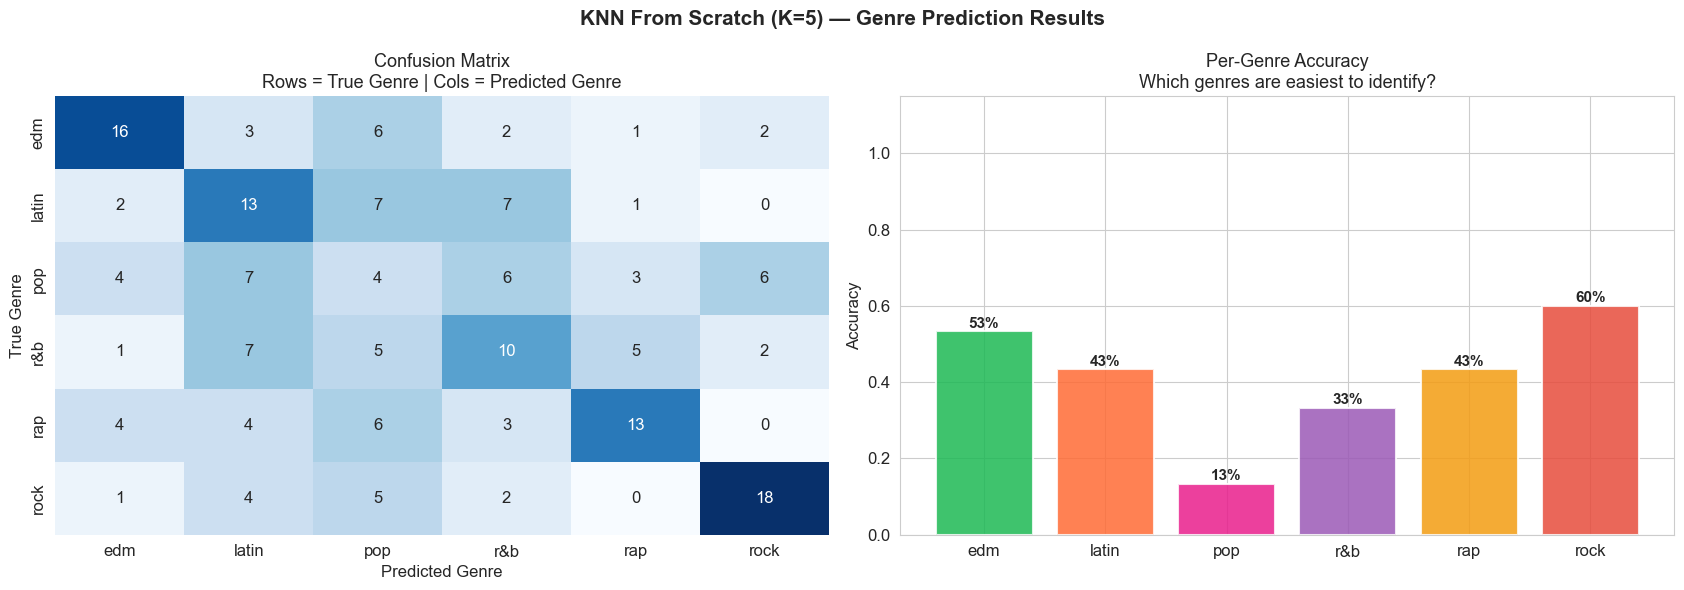

Most common mistake: predicted pop    when true genre was latin  (7 times)

Does this match your prediction from before?


In [20]:
# ── TASK 6.2 ── 6-genre confusion matrix ──────────────────────────────────────

# Step 1: Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_scratch)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('KNN From Scratch (K=5) — Genre Prediction Results',
             fontsize=15, fontweight='bold')

# Step 2: Heatmap (left panel)
# YOUR CODE HERE ---------------------------------------------------------------
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix\nRows = True Genre | Cols = Predicted Genre')
axes[0].set_xlabel('Predicted Genre')
axes[0].set_ylabel('True Genre')

# Step 3: Per-genre accuracy bar chart (right panel)
# Diagonal of CM divided by row sums = per-class accuracy
per_genre_acc = cm.diagonal() / cm.sum(axis=1)

colors = [GENRE_COLORS[g] for g in le.classes_]
bars   = axes[1].bar(le.classes_, per_genre_acc, color=colors,
                     edgecolor='white', linewidth=1.5, alpha=0.85)
for bar, val in zip(bars, per_genre_acc):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val*100:.0f}%',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Per-Genre Accuracy\nWhich genres are easiest to identify?')
axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.savefig('05_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# Step 4: Find the most common mistake
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
mistake_idx = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
print(f'Most common mistake: predicted {le.classes_[mistake_idx[1]]:6s} '
      f'when true genre was {le.classes_[mistake_idx[0]]}  '
      f'({cm_no_diag[mistake_idx]} times)')
print()
print('Does this match your prediction from before?')


---

## Part 7 — Finding the Best K

### Task 7.1 — Sweep K Values

Test K values across a range and record accuracy on the test set.

**INSTRUCTIONS:**
1. Test these K values: `k_values = [1, 3, 5, 7, 9, 11, 15, 21]`
2. For each K, create and fit a `KNNClassifier`, compute test accuracy
3. Also compute train accuracy on a **subsample of 120 training songs** for speed
4. Store results in `train_accs` and `test_accs`
5. Print each result as you go

**HINT for subsample:**
```python
rng     = np.random.RandomState(42)
sub_idx = rng.choice(len(X_train_sc), 120, replace=False)
tr_acc  = np.mean(m.predict(X_train_sc[sub_idx]) == y_train[sub_idx])
```


In [ ]:
# ── TASK 7.1 ── K sweep ────────────────────────────────────────────────────────

k_values   = [1, 3, 5, 7, 9, 11, 15, 21]
train_accs = []
test_accs  = []
rng        = np.random.RandomState(42)
sub_idx    = rng.choice(len(X_train_sc), 120, replace=False)

for k in k_values:
    print(f'  K={k:2d} ...', end='  ')

    # YOUR CODE HERE: create model, fit, compute train and test accuracy
    m = KNNClassifier(k=k, metric='euclidean')
    m.fit(X_train_sc[sub_idx], y_train[sub_idx])
    y_pred  = m.predict(X_train_sc[sub_idx])
    tr_acc  = m.score(X_train_sc[sub_idx], y_train[sub_idx])
    te_acc  = m.score(X_test_sc, y_test)


    train_accs.append(tr_acc)
    test_accs.append(te_acc)
    print(f'Train(subsample) = {tr_acc:.3f}   Test = {te_acc:.3f}')

best_k_scratch = k_values[np.argmax(test_accs)]
print(f'\nBest K = {best_k_scratch}  (Test Accuracy = {max(test_accs)*100:.2f}%)')


  K= 1 ...  Train(subsample) = 1.000   Test = 0.344
  K= 3 ...  Train(subsample) = 0.858   Test = 0.328
  K= 5 ...  Train(subsample) = 0.675   Test = 0.361
  K= 7 ...  Train(subsample) = 0.625   Test = 0.317
  K= 9 ...  Train(subsample) = 0.625   Test = 0.317
  K=11 ...  Train(subsample) = 0.550   Test = 0.311
  K=15 ...  Train(subsample) = 0.508   Test = 0.300
  K=21 ...  Train(subsample) = 0.475   Test = 0.317

Best K = 5  (Test Accuracy = 36.11%)


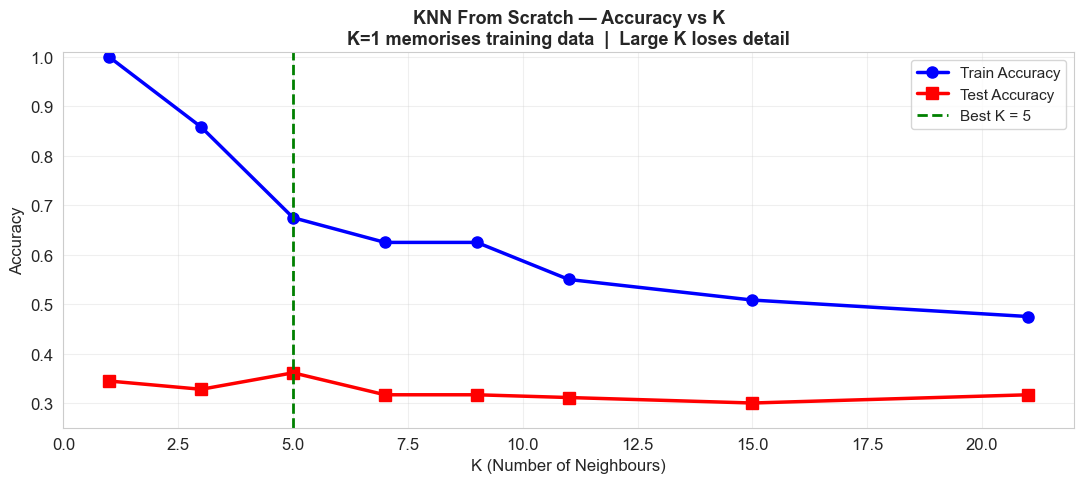

Where does overfitting appear in this chart?
Where does underfitting appear?


In [ ]:
# ── TASK 7.2 ── Plot the K sweep curve ────────────────────────────────────────
#
# INSTRUCTIONS:
#   - Plot train accuracy as a blue line with circle markers
#   - Plot test accuracy as a red line with square markers
#   - Add a vertical green dashed line at best_k_scratch
#   - Shade the region between the two lines (shows train-test gap)
#   - Set y-axis range to [0.25, 1.01]
#
# HINTS:
#   ax.plot(k_values, train_accs, 'b-o', ms=8, lw=2.5, label='Train Accuracy')
#   ax.fill_between(k_values, train_accs, test_accs, alpha=0.1, color='gray')

fig, ax = plt.subplots(figsize=(11, 5))

# YOUR CODE HERE ---------------------------------------------------------------
ax.plot(k_values, train_accs, 'b-o', ms=8, lw=2.5, label='Train Accuracy')
ax.plot(k_values, test_accs, 'r-s', ms=8, lw=2.5, label='Test Accuracy')
ax.axvline(x=best_k_scratch, color='g', linestyle='--', linewidth=2, label=f'Best K = {best_k_scratch}')

ax.set_xlabel('K (Number of Neighbours)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('KNN From Scratch — Accuracy vs K\n'
             'K=1 memorises training data  |  Large K loses detail',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0.25, 1.01)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('06_k_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

print('Where does overfitting appear in this chart?')
print('Where does underfitting appear?')


---

## Part 8 — Comparing Distance Metrics

### Task 8.1 — Euclidean vs Manhattan on Music Data

**Before running:** which distance metric do you think will work better on audio features?

- Audio features like `danceability` and `valence` are bounded [0, 1]
- `tempo` can be anywhere from 50 to 200+ BPM
- `loudness` is typically -60 to 0 dB

With features on very different scales (even after scaling), one metric might
capture genre similarity better than the other.

**INSTRUCTIONS:**
1. Test both metrics at K = 5 and K = best_k_scratch
2. Create a grouped bar chart comparing accuracies
3. Print which metric is better and by how much


  Testing K=5, euclidean...  Test accuracy = 36.11%
  Testing K=5, manhattan...  Test accuracy = 36.67%



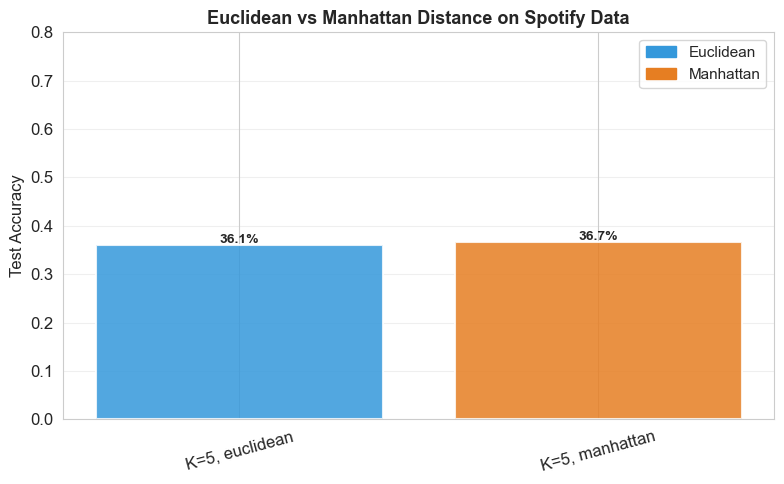

In [ ]:
# ── TASK 8.1 ── Euclidean vs Manhattan ────────────────────────────────────────

k_to_test = [5, best_k_scratch] if best_k_scratch != 5 else [5]
results   = {}

for k in k_to_test:
    for metric in ['euclidean', 'manhattan']:
        key = f'K={k}, {metric}'
        print(f'  Testing {key}...', end='  ')

        # YOUR CODE HERE: create model, fit, score
        m   = KNNClassifier(k=k, metric=metric)
        m.fit(X_train_sc[sub_idx], y_train[sub_idx])
        acc = m.score(X_test_sc, y_test)



        results[key] = acc
        print(f'Test accuracy = {acc*100:.2f}%')

        print()

# Bar chart
fig, ax = plt.subplots(figsize=(max(8, len(results)*1.5), 5))
colors  = ['#3498db' if 'euclidean' in k else '#e67e22' for k in results]
bars    = ax.bar(results.keys(), results.values(),
                 color=colors, edgecolor='white', lw=1.5, alpha=0.85)
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Euclidean vs Manhattan Distance on Spotify Data', fontsize=13, fontweight='bold')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0, 0.80)
ax.tick_params(axis='x', rotation=15)

# Legend
eu_patch = mpatches.Patch(color='#3498db', label='Euclidean')
mn_patch = mpatches.Patch(color='#e67e22', label='Manhattan')
ax.legend(handles=[eu_patch, mn_patch], fontsize=11)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('07_metric_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


---

## Part 9 — Benchmark Against Sklearn

### Task 9.1 — Cross-Validation K Search

Sklearn's KNN uses KD-trees so it runs much faster than our Python loops.
This lets us do a thorough search of K=1 to 40 with 10-fold cross-validation.

**INSTRUCTIONS:**
1. Loop through `k_range = range(1, 41)`
2. For each K run `cross_val_score` with `cv=10`
3. Record mean and std of the CV scores
4. Find and print the best K

**HINT:**
```python
scores = cross_val_score(
    KNeighborsClassifier(n_neighbors=k),
    X_train_sc, y_train, cv=10
)
cv_means.append(scores.mean())
cv_stds.append(scores.std())
```


In [ ]:
# ── TASK 9.1 ── CV K sweep with sklearn ───────────────────────────────────────

k_range  = range(1, 41)
cv_means = []
cv_stds  = []

print('Running 10-fold cross-validation for K=1 to 40...')
for k in k_range:
    # YOUR CODE HERE -----------------------------------------------------------
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=k)
                             , X_train_sc, y_train, cv=10, scoring='accuracy')
    cv_means.append(np.mean(scores))
    cv_stds.append(np.std(scores))
    cv_means.appenD(np.mean(scores))

cv_means  = np.array(cv_means)
cv_stds   = np.array(cv_stds)
best_k_cv = list(k_range)[np.argmax(cv_means)]

print(f'Best K = {best_k_cv}  (CV Accuracy = {max(cv_means)*100:.2f}%)')


Running 10-fold cross-validation for K=1 to 40...
Best K = 37  (CV Accuracy = 44.72%)


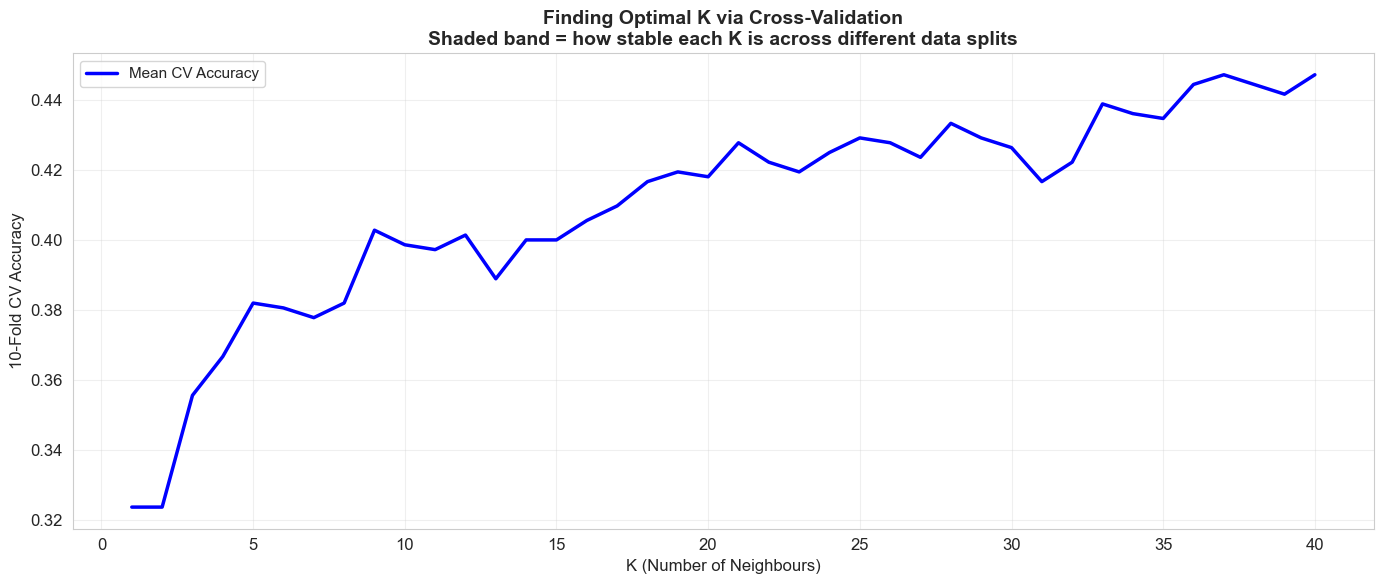

In [26]:
# ── TASK 9.2 ── Plot the cross-validation curve ────────────────────────────────
#
# INSTRUCTIONS:
#   - Plot mean CV accuracy as a line
#   - Add shaded band for +/- 1 std deviation
#   - Mark the best K with a vertical dashed line
#   - Mark where your scratch implementation's best K falls (best_k_scratch)
#
# HINTS:
#   ax.fill_between(list(k_range), cv_means-cv_stds, cv_means+cv_stds, alpha=0.2)
#   ax.axvline(x=best_k_cv, ...)
#   ax.axvline(x=best_k_scratch, color='green', ls=':', label='Your scratch best K')

fig, ax = plt.subplots(figsize=(14, 6))

# YOUR CODE HERE ---------------------------------------------------------------
ax.plot(list(k_range), cv_means, 'b-', lw=2.5, label='Mean CV Accuracy')

ax.set_xlabel('K (Number of Neighbours)', fontsize=12)
ax.set_ylabel('10-Fold CV Accuracy', fontsize=12)
ax.set_title('Finding Optimal K via Cross-Validation\n'
             'Shaded band = how stable each K is across different data splits',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('08_cv_sweep.png', dpi=120, bbox_inches='tight')
plt.show()


### Task 9.3 — Final Head-to-Head: Your KNN vs Sklearn

**INSTRUCTIONS:**
1. Train sklearn `KNeighborsClassifier(n_neighbors=best_k_cv)` and predict
2. Train your `KNNClassifier(k=best_k_cv)` and predict
3. Compute agreement: what % of songs do both models classify identically?
4. Show a side-by-side accuracy comparison


Training scratch KNN with K=37...

  FINAL COMPARISON   K = 37
  Your KNN from scratch : 45.00%
  Sklearn KNeighbors    : 44.44%
  Prediction agreement  : 95.0%

  Check your _predict_one logic for bugs.


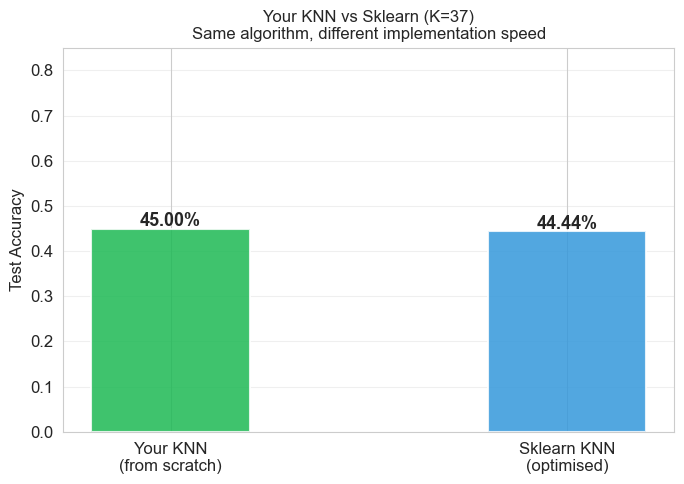

In [27]:
# ── TASK 9.3 ── Final comparison ──────────────────────────────────────────────

# Sklearn model
knn_sklearn    = KNeighborsClassifier(n_neighbors=best_k_cv, metric='euclidean')
knn_sklearn.fit(X_train_sc, y_train)
y_pred_sklearn = knn_sklearn.predict(X_test_sc)
acc_sklearn    = knn_sklearn.score(X_test_sc, y_test)

# Your scratch model with the same best K
print(f'Training scratch KNN with K={best_k_cv}...')
knn_best    = KNNClassifier(k=best_k_cv, metric='euclidean')
knn_best.fit(X_train_sc, y_train)
y_pred_best = knn_best.predict(X_test_sc)
acc_best    = knn_best.score(X_test_sc, y_test)

# Agreement
agreement = np.mean(y_pred_best == y_pred_sklearn)  # fraction of identical predictions
             # HINT: np.mean(y_pred_best == y_pred_sklearn)

print()
print('=' * 52)
print(f'  FINAL COMPARISON   K = {best_k_cv}')
print('=' * 52)
print(f'  Your KNN from scratch : {acc_best*100:.2f}%')
print(f'  Sklearn KNeighbors    : {acc_sklearn*100:.2f}%')
print(f'  Prediction agreement  : {agreement*100:.1f}%')
print()
if agreement >= 0.97:
    print('  Your implementation matches sklearn.')
else:
    print('  Check your _predict_one logic for bugs.')

# Bar chart
fig, ax = plt.subplots(figsize=(7, 5))
labels = ['Your KNN\n(from scratch)', 'Sklearn KNN\n(optimised)']
accs   = [acc_best, acc_sklearn]
cols   = ['#1DB954', '#3498db']
bars   = ax.bar(labels, accs, color=cols, width=0.4,
                edgecolor='white', lw=1.5, alpha=0.85)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val*100:.2f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_title(f'Your KNN vs Sklearn (K={best_k_cv})\nSame algorithm, different implementation speed',
             fontsize=12)
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0, 0.85)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('09_final_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


---

## Bonus Challenges

---

### Bonus A — Predict Your Own Song

Every Spotify track has an audio analysis page. You can find the features for
any song using the Spotify Web API or third-party tools like:
- https://www.chosic.com/spotify-audio-analysis/
- Search "Spotify audio features [song name]"

Paste the values into the cell below and see what genre your KNN predicts!


In [ ]:
# ── BONUS A ── Predict your own song ──────────────────────────────────────────
#
# INSTRUCTIONS:
#   1. Look up the audio features for any song you like.
#   2. Fill in the values below.
#   3. Run the cell to see what genre your KNN predicts.
#   4. Does the prediction make sense?

# Example: fill in your song's values here
# (these are the features in the same order as FEATURES list)
#                  dance  energy  loud    speech  acoustic  instru  live   valence  tempo   duration_ms
my_song_values = [  0.65,  0.72,  -5.4,   0.08,    0.12,    0.001,  0.15,   0.54,  120.0,   210000   ]

my_song_name = 'My Song Title Here'   # Change this!

# Step 1: Scale the values using the SAME scaler fitted on training data
my_song_array = np.array(my_song_values).reshape(1, -1)
my_song_sc    = ???   # HINT: scaler.transform(my_song_array)

# Step 2: Predict using your best scratch model
predicted_encoded = ???   # knn_best.predict(my_song_sc)
predicted_genre   = ???   # le.inverse_transform(predicted_encoded)[0]

# Step 3: Get distances to the 5 nearest neighbours (for interpretability)
# Find the 5 training songs most similar to your song
distances_to_train = np.array([euclidean_distance(my_song_sc[0], xt) for xt in X_train_sc])
nearest_idx        = np.argsort(distances_to_train)[:5]

print(f'Song: {my_song_name}')
print(f'Predicted genre: {predicted_genre.upper()}')
print()
print('5 nearest training neighbours:')
# Map back to original DataFrame rows
train_indices = df_balanced.index[np.where(
    np.isin(np.arange(len(df_balanced)),
            np.argsort(distances_to_train)[:5])
)[0]] if False else nearest_idx  # simplified version

for rank, idx in enumerate(nearest_idx[:5]):
    genre_name = le.inverse_transform([y_train[idx]])[0]
    print(f'  {rank+1}. Genre: {genre_name:6s}   Distance: {distances_to_train[idx]:.4f}')


### Bonus B — Add Weighted Voting to Your Classifier

In [ ]:
# ── BONUS B ── Distance-weighted KNN ──────────────────────────────────────────
#
# Standard KNN gives every neighbour 1 equal vote.
# Weighted KNN gives each neighbour weight = 1 / distance.
# A closer neighbour influences the prediction more.
#
# INSTRUCTIONS:
#   Extend KNNClassifier into a new class KNNClassifierWeighted.
#   Add a 'weights' parameter ('uniform' or 'distance') to __init__.
#   In _predict_one, when weights='distance':
#     1. Compute k_distances for the K nearest neighbours
#     2. weights_arr = 1.0 / (k_distances + 1e-8)
#     3. Build dict: for each neighbour, add its weight to class_votes[label]
#     4. Return the label with highest total weight

class KNNClassifierWeighted(KNNClassifier):

    def __init__(self, k=5, metric='euclidean', weights='uniform'):
        super().__init__(k=k, metric=metric)
        self.weights = weights

    def _predict_one(self, x):
        # Step 1: distances to all training points
        distances  = ???
        # Step 2: sort and take K nearest
        sorted_idx = ???
        k_idx      = sorted_idx[:self.k]
        k_labels   = self.y_train[k_idx]
        k_dists    = distances[k_idx]

        if self.weights == 'uniform':
            # Same as original majority vote
            return Counter(k_labels).most_common(1)[0][0]

        # Distance weighted voting
        # YOUR CODE HERE -------------------------------------------------------
        ???


# Compare uniform vs weighted
print('Comparing uniform vs distance-weighted KNN (K=7):')
m_u = KNNClassifierWeighted(k=7, weights='uniform')
m_u.fit(X_train_sc, y_train)
acc_u = m_u.score(X_test_sc, y_test)

m_d = KNNClassifierWeighted(k=7, weights='distance')
m_d.fit(X_train_sc, y_train)
acc_d = m_d.score(X_test_sc, y_test)

print(f'  Uniform  weights K=7: {acc_u*100:.2f}%')
print(f'  Distance weights K=7: {acc_d*100:.2f}%')
print(f'  Weighted is {"better" if acc_d > acc_u else "not better"} on this dataset.')


### Bonus C — Which Genres Are Hardest to Tell Apart?

In [ ]:
# ── BONUS C ── Genre confusion analysis ───────────────────────────────────────
#
# Use the confusion matrix from the sklearn model to find:
# 1. The 3 most commonly confused genre PAIRS
# 2. Plot their feature distributions side by side to understand WHY
#    they overlap (pick 2-3 features where they look most similar)
#
# INSTRUCTIONS:
#   1. Get the confusion matrix for knn_sklearn predictions
#   2. Set diagonal to 0 (remove correct predictions)
#   3. Find the top 3 off-diagonal cells
#   4. For each confused pair, plot histograms of 2-3 features

cm_analysis = confusion_matrix(y_test, y_pred_sklearn)
cm_no_diag  = cm_analysis.copy()
np.fill_diagonal(cm_no_diag, 0)

# Step 1: Find top 3 confusion pairs
# YOUR CODE HERE ---------------------------------------------------------------
# HINT: Use np.argsort(cm_no_diag.ravel())[::-1][:6] and np.unravel_index
pairs = ???

print('Top 3 most confused genre pairs:')
for rank, (true_idx, pred_idx) in enumerate(pairs[:3]):
    true_genre = le.classes_[true_idx]
    pred_genre = le.classes_[pred_idx]
    count      = cm_no_diag[true_idx, pred_idx]
    print(f'  {rank+1}. True={true_genre:6s} -> Predicted={pred_genre:6s}  ({count} times)')

print()
print('Step 2: For the most confused pair, plot 3 features that show WHY they overlap.')

# YOUR CODE HERE: create comparison plots for the top confused pair
???


---

## Final Reflection

Answer these after completing the lab.

---

**Question 1:** Look at the confusion matrix. Which two genres did KNN confuse most often?
Based on the audio feature plots from Part 2, does this make sense? Why?

*Your answer:*

---

**Question 2:** The balanced dataset used only 150 songs per genre out of thousands available.
How do you think using more training data would affect accuracy?
What would be the trade-off with your scratch implementation specifically?

*Your answer:*

---

**Question 3:** KNN achieved roughly 50-60% accuracy on 6 genres.
Random guessing would give ~17% (1/6). Is 50-60% good or bad?
What would make this task harder or easier for KNN?

*Your answer:*

---

**Question 4:** You tested both Euclidean and Manhattan distance.
Which was better on the Spotify data? Looking at the feature ranges,
why might one outperform the other here?

*Your answer:*

---

**Question 5:** Your scratch implementation took ~30 seconds.
sklearn took milliseconds. They produce the same predictions.
What does sklearn do differently under the hood to achieve this?

*Your answer:*


In [ ]:
# ── FINAL SUMMARY ─────────────────────────────────────────────────────────────
print('=' * 58)
print('  KNN SPOTIFY LAB   COMPLETION SUMMARY')
print('=' * 58)
print()
print('Dataset: Spotify Songs (TidyTuesday 2020)')
print(f'  900 songs   6 genres   10 audio features')
print()
print('What you built:')
print('  euclidean_distance()    from scratch')
print('  manhattan_distance()    from scratch')
print('  KNNClassifier class     from scratch')
print('    __init__  fit  _compute_distance')
print('    _predict_one  predict  score')
print()
print('Results:')
try: print(f'  Best K (scratch sweep) : {best_k_scratch}')
except: pass
try: print(f'  Best K (CV sweep)      : {best_k_cv}')
except: pass
try: print(f'  Your scratch accuracy  : {acc_best*100:.2f}%')
except: pass
try: print(f'  Sklearn accuracy       : {acc_sklearn*100:.2f}%')
except: pass
try: print(f'  Prediction agreement   : {agreement*100:.1f}%')
except: pass
print()
print('Concepts practiced:')
for c in [
    'Lazy learning: store data, no computation at train time',
    'Euclidean and Manhattan distance from scratch',
    'Feature scaling: non-negotiable for KNN',
    '6-class confusion matrix: which genres get mixed up',
    'Bias-variance tradeoff: small K vs large K',
    'Cross-validation: reliable way to pick K',
    'Benchmarking: matching sklearn with your own code',
]:
    print(f'  {c}')
